---
Q7. List the top 5 states with high EV adoption and analyse if their average AQI is 
significantly better compared to states with lower EV adoption
---

In [1]:
import pandas as pd
import numpy as np
vehicle_class=pd.read_csv('vehicle_class.csv')

In [2]:
vehicle_class['fuel'].unique()

array(['DIESEL', 'PETROL', 'ELECTRIC(BOV)', 'PETROL/ETHANOL', 'PURE EV',
       'PETROL/HYBRID', 'STRONG HYBRID EV', 'CNG ONLY', 'PETROL/CNG',
       'ETHANOL', 'DIESEL/HYBRID', 'NOT APPLICABLE', 'LPG ONLY',
       'PLUG-IN HYBRID EV', 'LNG', 'DUAL DIESEL/LNG', 'PETROL/LPG',
       'FUEL CELL HYDROGEN', 'SOLAR', 'DUAL DIESEL/CNG', 'METHANOL',
       'BS IV', 'BS III', 'EURO 3', 'Not Available', 'BS II',
       'BS III (CEV)', 'B(T)S III A', 'BS III/IV', 'EURO 4', 'B(T)S III',
       'BS I', 'EURO 1', 'B(T)S IV', 'EURO 2', 'B(T)S III B', 'B(T)S V',
       'BS VI'], dtype=object)

In [8]:
data=pd.read_csv('day-wise-state-wise-air-quality-index-aqi-of-major-cities-and-towns-in-india.csv')
# avg AQI by states
data['date']=pd.to_datetime(data['date'],format='%d-%m-%Y')
state_aqi_filter=data[data['date']>='2022-01-01']
state_aqi_avg=state_aqi_filter.groupby('state')['aqi_value'].mean().reset_index(name='avg_aqi')
state_aqi_avg


electric_vehicles=vehicle_class[vehicle_class['fuel'].str.contains('ELECTRIC|EV',na=False)]
res=electric_vehicles.groupby('state')['value'].sum().reset_index(name='vehicles_count')
res.sort_values(by='vehicles_count',ascending=False)
ev_nd_aqi=pd.merge(res,state_aqi_avg[['state','avg_aqi']],on='state')
ev_nd_aqi.sort_values(by='vehicles_count',ascending=False)

,state,vehicles_count,avg_aqi
28,Uttar Pradesh,1180447,128.607838
16,Maharashtra,695102,102.794081
13,Karnataka,532380,63.153353
7,Delhi,374468,207.392095
26,Tamil Nadu,373260,66.377613
24,Rajasthan,356229,127.464524
4,Bihar,343224,160.371841
8,Gujarat,267201,111.626806
15,Madhya Pradesh,247780,109.423128
14,Kerala,234848,68.493114


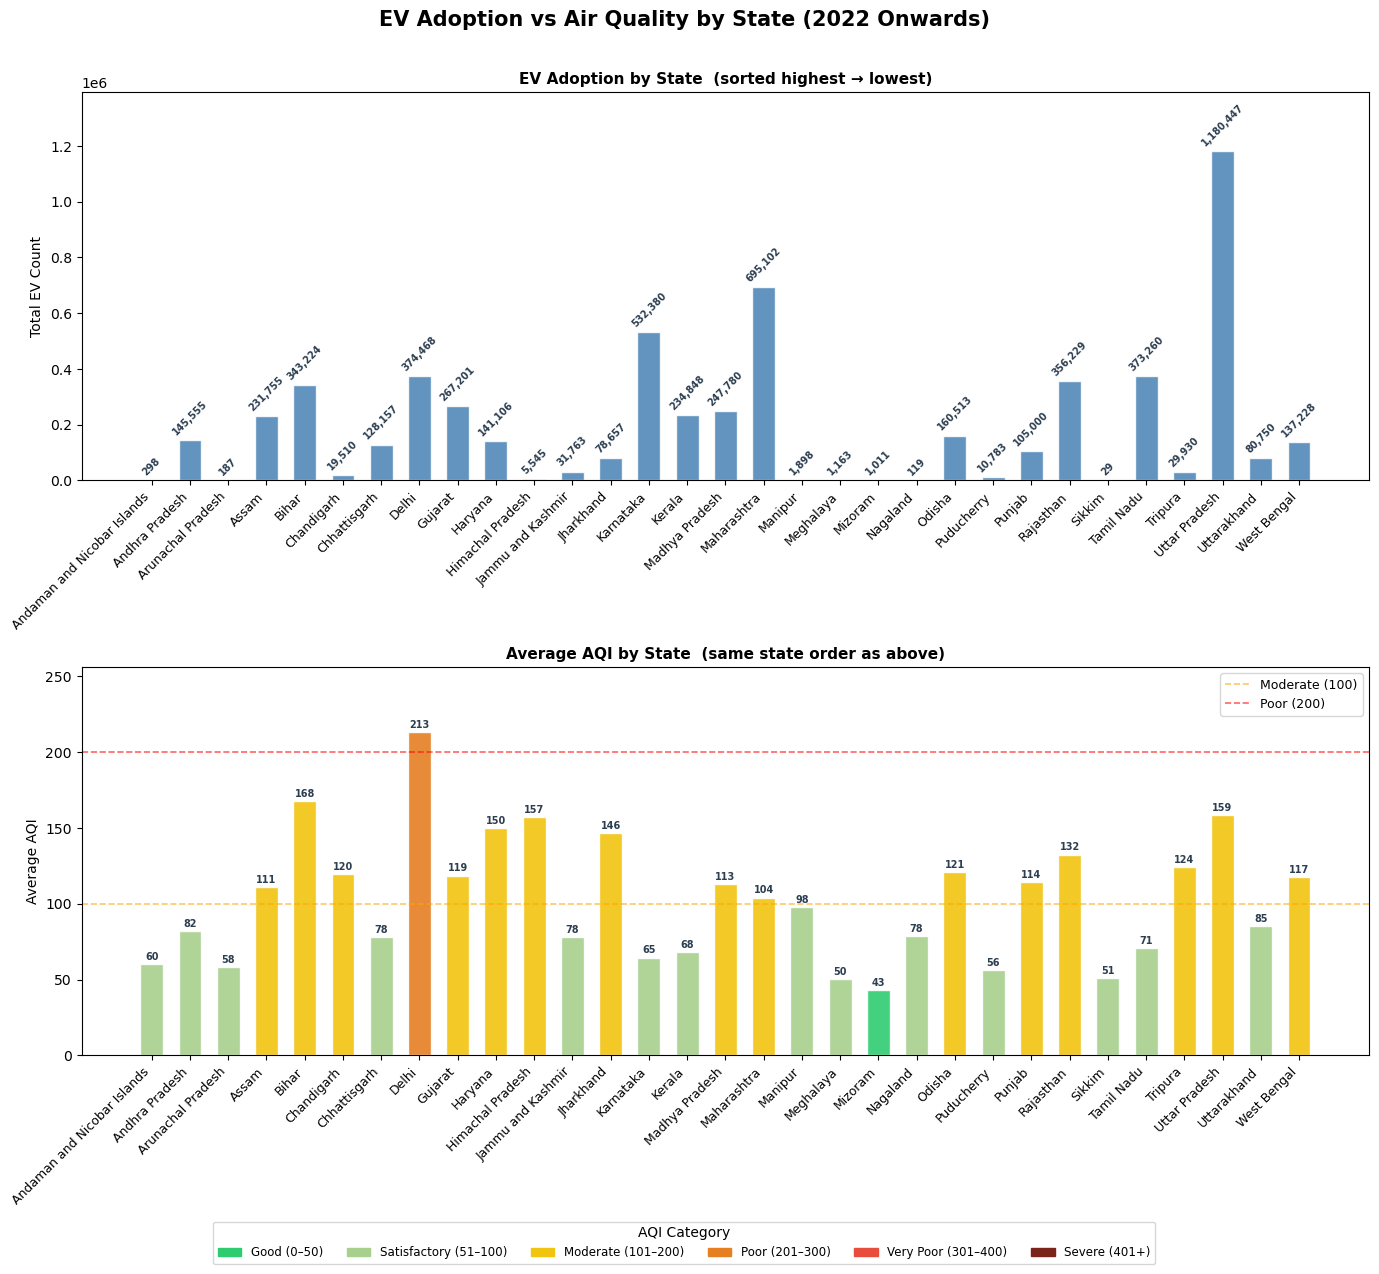

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ─── AQI color function ───────────────────────────────────────────────────────
def aqi_color(val):
    if val <= 50:     return '#2ecc71'
    elif val <= 100:  return '#a8d08d'
    elif val <= 200:  return '#f1c40f'
    elif val <= 300:  return '#e67e22'
    elif val <= 400:  return '#e74c3c'
    else:             return '#7b241c'

# ─── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle('EV Adoption vs Air Quality by State (2022 Onwards)',
             fontsize=15, fontweight='bold', y=1.01)

states  = ev_nd_aqi['state']
x       = np.arange(len(states))
colors  = [aqi_color(v) for v in ev_nd_aqi['avg_aqi']]

# ─── Chart 1: EV Count per State ─────────────────────────────────────────────
bars = axes[0].bar(x, ev_nd_aqi['vehicles_count'],
                   color='steelblue', alpha=0.85,
                   edgecolor='white', width=0.6)

for bar, val in zip(bars, ev_nd_aqi['vehicles_count']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + ev_nd_aqi['vehicles_count'].max() * 0.01,
                 f'{int(val):,}',
                 ha='center', va='bottom', fontsize=7, fontweight='bold',
                 color='#2c3e50', rotation=45)

axes[0].set_xticks(x)
axes[0].set_xticklabels(states, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('Total EV Count', fontsize=10)
axes[0].set_title('EV Adoption by State  (sorted highest → lowest)',
                  fontsize=11, fontweight='bold')
axes[0].set_ylim(0, ev_nd_aqi['vehicles_count'].max() * 1.18)

# ─── Chart 2: Avg AQI per State (same order) ─────────────────────────────────
bars2 = axes[1].bar(x, ev_nd_aqi['avg_aqi'],
                    color=colors, alpha=0.90,
                    edgecolor='white', width=0.6)

for bar, val in zip(bars2, ev_nd_aqi['avg_aqi']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1.5,
                 f'{val:.0f}',
                 ha='center', va='bottom', fontsize=7,
                 fontweight='bold', color='#2c3e50')

# Threshold lines
axes[1].axhline(y=100, color='orange', linestyle='--',
                alpha=0.6, linewidth=1.2, label='Moderate (100)')
axes[1].axhline(y=200, color='red', linestyle='--',
                alpha=0.6, linewidth=1.2, label='Poor (200)')

axes[1].set_xticks(x)
axes[1].set_xticklabels(states, rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('Average AQI', fontsize=10)
axes[1].set_title('Average AQI by State  (same state order as above)',
                  fontsize=11, fontweight='bold')
axes[1].set_ylim(0, ev_nd_aqi['avg_aqi'].max() * 1.2)
axes[1].legend(fontsize=9)

# ─── AQI color legend ─────────────────────────────────────────────────────────
aqi_legend = [
    mpatches.Patch(color='#2ecc71', label='Good (0–50)'),
    mpatches.Patch(color='#a8d08d', label='Satisfactory (51–100)'),
    mpatches.Patch(color='#f1c40f', label='Moderate (101–200)'),
    mpatches.Patch(color='#e67e22', label='Poor (201–300)'),
    mpatches.Patch(color='#e74c3c', label='Very Poor (301–400)'),
    mpatches.Patch(color='#7b241c', label='Severe (401+)'),
]
fig.legend(handles=aqi_legend, loc='lower center', ncol=6,
           fontsize=8.5, title='AQI Category',
           bbox_to_anchor=(0.5, -0.04), frameon=True)

plt.tight_layout()
plt.show()

**Conclusion :**EV adoption is not a threat to AirPure's market. Even in states with the highest EV penetration, indoor air quality remains compromised. The product's value proposition is durable regardless of India's EV transition timeline- positioning **AirPure** as a long-term household necessity rather than a short-term pollution stopgap.